# RetainIQ — Retention Funnel (Customer Lifecycle Stages)

A new analytical capability, not a Phase 1 EDA deep-dive: nothing in the repo assigns customers to a lifecycle/relationship stage today. All logic lives in `src/data/lifecycle.py` — this notebook only calls into it and renders the results.

**Design note:** the four stages — `New`, `Engaged`, `Loyal`, `At-Risk` — are not a simple tenure ladder. `At-Risk` is a **priority override**: a customer showing enough behavioral risk signals (contract type, payment method, tech support, internet type — all from CLAUDE.md §6's documented signal table) is classified `At-Risk` regardless of tenure, checked *before* the tenure/service-depth split. See `.claude/specs/05-retention-funnel.md` for the full methodology decision and why every threshold constant was chosen by inspecting churn-rate separation on this dataset, not guessed.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.config import FIGURES_DIR
from src.data.cohorts import TENURE_COHORT_BOUNDARIES, cohort_summary
from src.data.load_data import load_clean_data
from src.data.lifecycle import (
    NEW_TENURE_MAX,
    generate_lifecycle_figures,
    lifecycle_summary,
    risk_signal_diagnostic,
)

pd.set_option("display.max_columns", None)
df = load_clean_data()
df.shape

(7043, 20)

Regenerate the lifecycle charts before rendering any of them below, so the images this notebook displays are always current for whatever `df` was just loaded.

In [2]:
paths = generate_lifecycle_figures(df)
print(f"Saved {len(paths)} figures to reports/figures/")

Saved 2 figures to reports/figures/


## 1. Risk-signal construction (disclosure table)

Four CLAUDE.md §6-documented risk indicators are counted per customer (0–4): `Contract == "Month-to-month"`, `PaymentMethod == "Electronic check"`, `TechSupport == "No"`, `InternetService == "Fiber optic"`. `tenure` is deliberately excluded from this count — it drives the base New/Engaged/Loyal split separately, so including it here would double-count the same signal. `Churn` is never read to *compute* the count — only afterward, to report the churn rate per count value below.

In [3]:
diagnostic = risk_signal_diagnostic(df)
display(diagnostic)

,risk_count,customers,churn_rate
0,0,1691,2.60
1,1,1513,13.02
2,2,1359,24.14
3,3,1342,43.52
4,4,1138,62.92


Churn rate climbs monotonically and steeply with the risk-signal count — from 2.60% at 0 signals to 62.92% at 4 signals, a >24x spread. This is what justifies combining the four signals into a single `AT_RISK_SIGNAL_THRESHOLD = 3` override rather than treating tenure as the only driver of retention risk.

## 2. Stage-assignment logic

Every customer gets exactly one stage, assigned in this priority order:

1. **At-Risk** — if the risk-signal count is ≥ `AT_RISK_SIGNAL_THRESHOLD` (3 of 4), regardless of tenure.
2. **New** — otherwise, if `tenure <= NEW_TENURE_MAX` (12 months).
3. **Loyal** — otherwise, if `tenure >= LOYAL_TENURE_MIN` (24 months) **and** `ServiceCount >= LOYAL_SERVICE_MIN` (5) — long tenure alone is not enough; a long-tenured but lightly-subscribed customer falls through to Engaged instead.
4. **Engaged** — everyone else (the catch-all — no customer is left unassigned).

## 3. Stage summary

In [4]:
summary = lifecycle_summary(df)
display(summary)

,stage,customers,avg_tenure,avg_service_count,churn_rate
0,New,1079,4.95,2.36,27.71
1,Engaged,1720,39.35,2.37,6.28
2,Loyal,1764,57.08,6.80,9.18
3,At-Risk,2480,21.89,4.26,52.42


The four stages read as commercially distinct groups:

- **New** (1,079 customers): avg tenure 4.95 mo, avg ServiceCount 2.36 — brand-new accounts that haven't yet shown enough risk behavior to be flagged At-Risk.
- **Engaged** (1,720 customers): avg tenure 39.35 mo, avg ServiceCount 2.37 — established but still lightly-subscribed.
- **Loyal** (1,764 customers): avg tenure 57.08 mo, avg ServiceCount 6.80 — long-tenured **and** multi-service, matching the literal "long-tenure, multi-service" request.
- **At-Risk** (2,480 customers): avg tenure 21.89 mo — a *moderate* average tenure, not a long one, showing this stage is driven by behavior, not by being new.

## 4. Lifecycle stage distribution

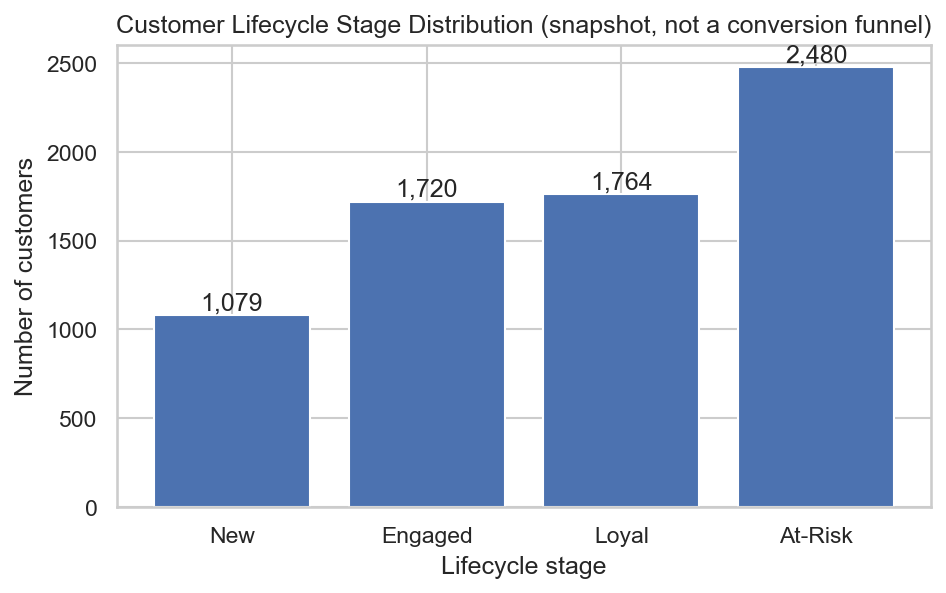

In [5]:
display(Image(str(FIGURES_DIR / "lifecycle_stage_distribution.png")))

**This is a stage distribution over a single snapshot, not a sequential conversion funnel.** Stage counts do not decrease monotonically (New=1,079 < Engaged=1,720 < Loyal=1,764 < At-Risk=2,480) — the four stages are mutually-exclusive categories of the current customer base, not nested drop-off stages of a pipeline. A literal narrowing "funnel" shape would misrepresent the data.

## 5. Churn rate by lifecycle stage

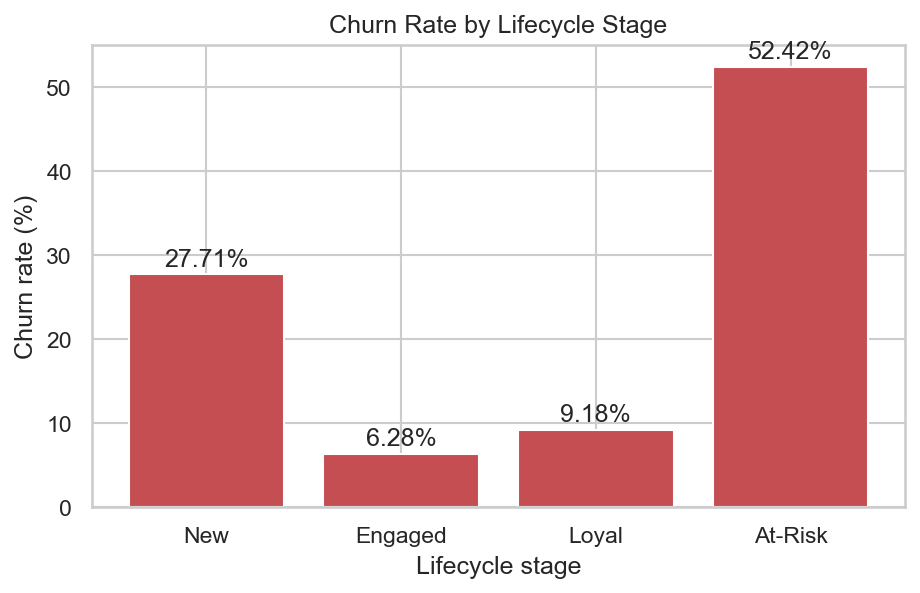

In [6]:
display(Image(str(FIGURES_DIR / "lifecycle_churn_rate.png")))

**At-Risk churns at more than 2x the rate of any other stage** (52.42% vs. the next-highest, New, at 27.71%) — and it does so at a *moderate* average tenure (21.89 mo), confirming behavioral risk signals separate churn risk better than tenure alone.

**The override also sharpens the New-customer story.** Without the At-Risk override, `cohorts.py`'s `"0-12"` tenure cohort churns at 47.44% (recomputed live below for comparison). After carving the high-risk fraction of new customers out into At-Risk, the *remaining* New stage churns at 27.71% — the tenure effect and the behavioral-risk effect are both real, but conflating them overstates how much "just being new" explains on its own.

In [7]:
# This comparison is only fair if the two tenure boundaries actually agree --
# assert the coupling instead of assuming it (locked in by a dedicated test
# in tests/test_lifecycle.py too).
assert NEW_TENURE_MAX == TENURE_COHORT_BOUNDARIES[0]

zero_to_twelve = cohort_summary(df).set_index("cohort").loc["0-12", "churn_rate"]
new_stage = summary.set_index("stage").loc["New", "churn_rate"]
print(f"cohorts.py '0-12' churn rate (tenure alone):        {zero_to_twelve}%")
print(f"lifecycle.py 'New' churn rate (after At-Risk carve-out): {new_stage}%")

cohorts.py '0-12' churn rate (tenure alone):        47.44%
lifecycle.py 'New' churn rate (after At-Risk carve-out): 27.71%


## Key findings

- **A composite risk-signal count built purely from CLAUDE.md §6's own signal table is strongly and monotonically predictive of churn**: 2.60% (0 signals) → 13.02% → 24.14% → 43.52% → 62.92% (4 signals), a >24x spread.
- **At-Risk is a priority override, not a tenure band, and that design choice matters**: At-Risk customers churn at 52.42% — more than double the next-highest stage — despite only a moderate average tenure (21.89 mo). Behavioral signals separate churn risk better than tenure alone.
- **The New-customer churn story is partly a risk-signal story, not purely a tenure story**: raw tenure ≤ 12 months churns at 47.44% (`cohorts.py`), but once the At-Risk override carves out the high-risk fraction, the remaining New stage churns at 27.71% — still elevated, but roughly 20 points lower than the undifferentiated tenure-only view.
- **Loyal correctly requires both long tenure *and* service depth**: a long-tenured customer with few services falls to Engaged, not Loyal, distinguishing "stuck around" from "stuck around and bought in."
- All four threshold constants (`AT_RISK_SIGNAL_THRESHOLD=3`, `NEW_TENURE_MAX=12`, `LOYAL_TENURE_MIN=24`, `LOYAL_SERVICE_MIN=5`) are fixed, disclosed business-rule constants chosen by inspecting churn-rate separation on this dataset — not grid-searched or fit by any shipped function, and never derived from `Churn` at call time.